# Feature Summary - Student Habits & Performance Dataset

| Feature Name               | Description                                  | Data Type  | Range/Values                               |
|---------------------------|----------------------------------------------|------------|--------------------------------------------|
| student_id                | Unique identifier for each student           | String     | S1000 - S1999                              |
| age                       | Age of the student                           | Integer    | 17-24 years                                |
| gender                    | Gender                                       | Categorical| Female, Male, Other                        |
| study_hours_per_day       | Daily study hours                            | Float      | 0.0 - 8.3 hours                            |
| social_media_hours        | Daily social media usage hours               | Float      | 0.0 - 7.2 hours                            |
| netflix_hours             | Daily Netflix/streaming hours                | Float      | 0.0 - 5.4 hours                            |
| part_time_job             | Has part-time job                            | Categorical| Yes, No                                    |
| attendance_percentage     | Class attendance percentage                  | Float      | 56.7% - 100%                               |
| sleep_hours               | Average nightly sleep hours                  | Float      | 3.2 - 10.0 hours                           |
| diet_quality              | Self-reported diet quality                   | Categorical| Poor, Fair, Good                           |
| exercise_frequency        | Weekly exercise frequency                    | Integer    | 0 - 6 times/week                           |
| parental_education_level  | Highest education level of parents           | Categorical| None, High School, Bachelor's, Master's, PhD |
| internet_quality          | Quality of internet access                   | Categorical| Poor, Average, Good                        |
| mental_health_rating      | Self-reported mental health (1-10 scale)     | Integer    | 1 (Low) - 10 (High)                        |
| extracurricular_participation | Participates in extracurricular activities | Categorical| Yes, No                                    |
| exam_score                | Final exam score                             | Float      | 18.4 - 100.0                               |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline



In [3]:
df = pd.read_csv("student_habits_performance.csv")

In [5]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [7]:
# Genel bilgi
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [9]:
df.shape

(1000, 16)

In [11]:
df.dtypes

student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object

## Handling Missing Value

In [13]:
# Eksik değer sayıları
df.isnull().sum()


student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [15]:
# Eksik değer yüzdesi
(df.isnull().sum() / len(df)) * 100

student_id                       0.0
age                              0.0
gender                           0.0
study_hours_per_day              0.0
social_media_hours               0.0
netflix_hours                    0.0
part_time_job                    0.0
attendance_percentage            0.0
sleep_hours                      0.0
diet_quality                     0.0
exercise_frequency               0.0
parental_education_level         9.1
internet_quality                 0.0
mental_health_rating             0.0
extracurricular_participation    0.0
exam_score                       0.0
dtype: float64

In [17]:
df['parental_education_level'].value_counts(dropna=False)

parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64

In [19]:
# Replace all missing values (NaN) in the parental_education_level column of df_student with the most common value (mode) from that column.
df["parental_education_level"] = df["parental_education_level"].fillna(df["parental_education_level"].mode()[0])

In [21]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

## Checking Duplicate Value

In [23]:
def check_duplicates_report(df=df):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 80)
    print(f"🔍 Duplicate Analysis")
    print("=" * 80)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

check_duplicates_report()

🔍 Duplicate Analysis
✅ No duplicates found in 1,000 rows


## Data Quality Insights: Missing Values, Duplicates and Outliers.

### Missing Values Analysis
We carefully checked the datasets for any missing values.The only feature with missing values was parental_education_level. I filled these missing values with the most common category in that variable.
We have finished handling missing values for the parental_education_level feature.

### Duplicate Records Analysis
We checked the datasets for duplicate rows, since these could bias the model or affect performance metrics.
No duplicate records were found in the dataset, confirming that all 1,000 rows are unique.
Since there are no duplicates, the model will not be trained or tested on repeated data points. This helps keep the results reliable.

### Outliers Records Analysis
We also checked the datasets for outliers.
We found outliers in the following features: study_hours_per_day, social_media_hours, netflix_hours, and attendance_percentage.



In [25]:
# 4. Separate numerical and categorical variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"NUMERICAL VARIABLES ({len(numeric_cols)} total):")
for i, col in enumerate(numeric_cols, 1):
    print(f"  {i:2d}. {col}")
print()

print(f"CATEGORICAL VARIABLES ({len(categorical_cols)} total):")
for i, col in enumerate(categorical_cols, 1):
    print(f"  {i:2d}. {col}")
print("\n" + "="*70)


NUMERICAL VARIABLES (9 total):
   1. age
   2. study_hours_per_day
   3. social_media_hours
   4. netflix_hours
   5. attendance_percentage
   6. sleep_hours
   7. exercise_frequency
   8. mental_health_rating
   9. exam_score

CATEGORICAL VARIABLES (7 total):
   1. student_id
   2. gender
   3. part_time_job
   4. diet_quality
   5. parental_education_level
   6. internet_quality
   7. extracurricular_participation



## Detect outliers in numerical variables

In [16]:

# Detect outliers in numerical variables using the IQR or Z-score method.

num_cols = df.select_dtypes(include=['int64','float64']).columns  # Select numerical columns

# IQR method to detect outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)  # Lower 25% of data
    Q3 = data[column].quantile(0.75)  # Upper 75% of data
    IQR = Q3 - Q1                     # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR      # Lower limit
    upper_bound = Q3 + 1.5 * IQR      # Upper limit
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Check the number of outliers in each column
for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"Column {col} has {len(outliers)} outliers.")


Column age has 0 outliers.
Column study_hours_per_day has 7 outliers.
Column social_media_hours has 5 outliers.
Column netflix_hours has 4 outliers.
Column attendance_percentage has 3 outliers.
Column sleep_hours has 2 outliers.
Column exercise_frequency has 0 outliers.
Column mental_health_rating has 0 outliers.
Column exam_score has 2 outliers.


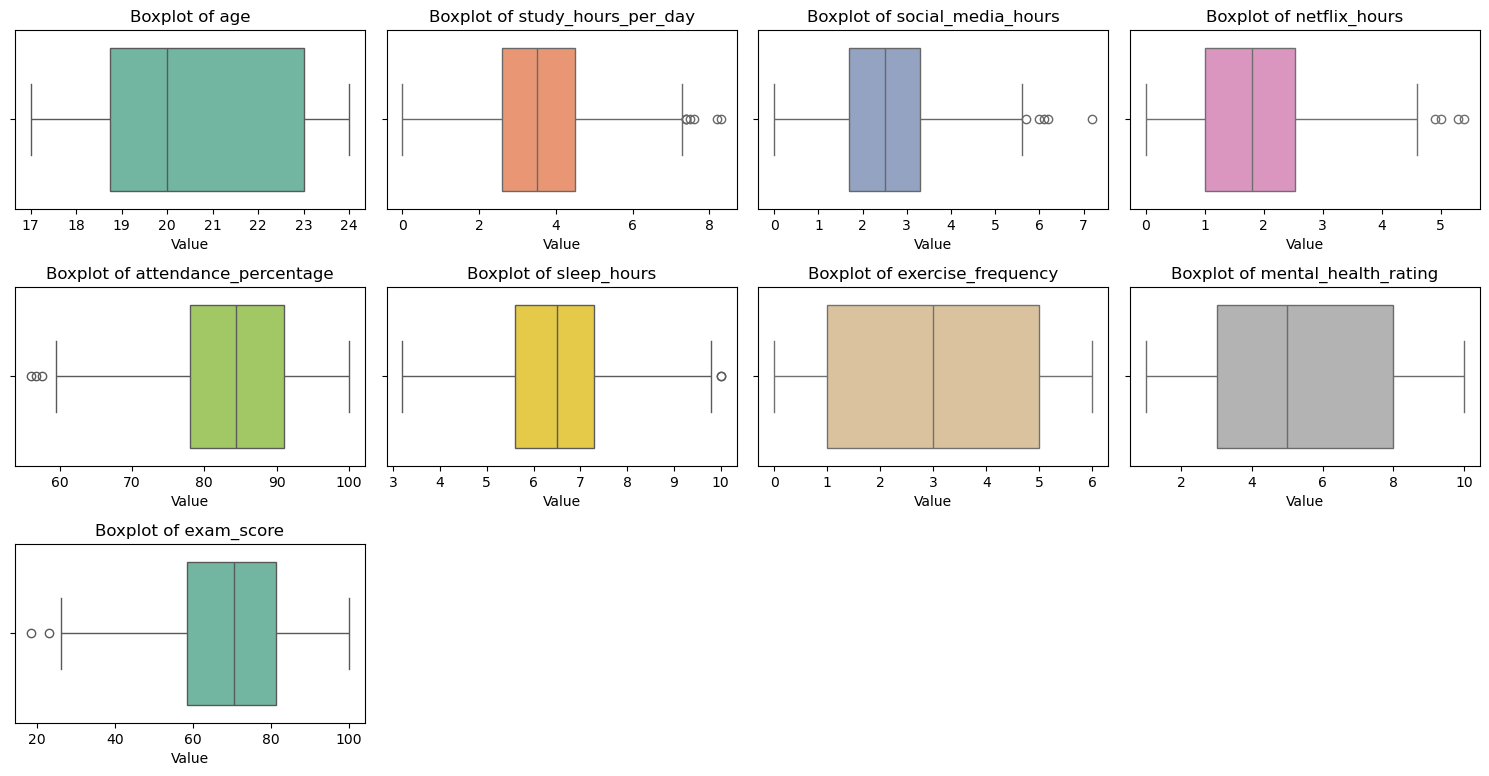

In [15]:
plt.figure(figsize=(15, 10))
palette = sns.color_palette("Set2", len(numeric_cols))  # Değişiklik burada

for i, (col, color) in enumerate(zip(numeric_cols, palette), 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df[col], color=color)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel('Value')

plt.tight_layout()
plt.show()

In this study, the Interquartile Range (IQR) method was used to detect outliers in numerical variables. The IQR method helps identify unusual values based on the range between the 25th and 75th percentiles of the data.

As a result of the analysis, a limited number of outliers were detected in some variables. In particular, there are a few extreme observations in variables such as daily study hours, social media usage, Netflix viewing time, and exam scores. However, the relatively low number of outliers indicates that they do not distort the overall structure of the dataset.

These values were not removed from the dataset because these observations may represent atypical student behaviors and performance differences that could occur in real life. Preserving outliers helps maintain the diversity and realism of the dataset

In [41]:
print("Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df.describe().T.style.background_gradient(cmap=cm))

Data describe:


,count,mean,std,min,25%,50%,75%,max
age,1000.000000,20.498000,2.308100,17.000000,18.750000,20.000000,23.000000,24.000000
study_hours_per_day,1000.000000,3.550100,1.468890,0.000000,2.600000,3.500000,4.500000,8.300000
social_media_hours,1000.000000,2.505500,1.172422,0.000000,1.700000,2.500000,3.300000,7.200000
netflix_hours,1000.000000,1.819700,1.075118,0.000000,1.000000,1.800000,2.525000,5.400000
attendance_percentage,1000.000000,84.131700,9.399246,56.000000,78.000000,84.400000,91.025000,100.000000
sleep_hours,1000.000000,6.470100,1.226377,3.200000,5.600000,6.500000,7.300000,10.000000
exercise_frequency,1000.000000,3.042000,2.025423,0.000000,1.000000,3.000000,5.000000,6.000000
mental_health_rating,1000.000000,5.438000,2.847501,1.000000,3.000000,5.000000,8.000000,10.000000
exam_score,1000.000000,69.601500,16.888564,18.400000,58.475000,70.500000,81.325000,100.000000


# Descriptive Insights from Dataset Statistics¶
We examined the summary statistics of the numerical features across the datasets. The statistics include count, mean, standard deviation, minimum, quartiles, and maximum values.

## age
The age range from 17 to 24, with a mean around 20.5 (very close to the median ⇒ the distribution is roughly symmetric, with no strong skewness) and a standard deviation of approximately 2.31 (Most students are within the range of 18 to 23 years old).
The IRQ between 18.75 (25th percentile) and 23 (75th percentile), meaning 50% of students are between 18.75 and 23 years old.

## study_hours_per_day
The value in range from 0 to 8.3, with a mean around 3.55 and a standard deviation is 3.5 (Most students are within the range of 0.05 to 7.05 hours to study per day).
The IRQ between 2.6 (25th percentile) and 4.5 (75th percentile), meaning 50% of students are between 2.6 and 4.5 hours to study per day.


## social_media_hours
The value in range from 0 to 7.2, with a mean around 2.5 and a standard deviation is 1.2 (Most students are within the range of 1.3 to 3.7 hours per day).
The IRQ between 1.7 (25th percentile) and 3.3 (75th percentile), meaning 50% of students are between 1.7 and 3.3 hours per day.

## netflix_hours
The value in range from 0 to 5.4, with a mean around 1.8 and a standard deviation is 1.07 (Most students are within the range of 0.73 to 2.87 hours per day).
The IRQ between 1 (25th percentile) and 2.52 (75th percentile), meaning 50% of students are between 1 and 2.52 hours per day.

## attendance_percentage
The value in range from 56 to 100, with a mean around 84.13 and a standard deviation is 9.4 (Most students are within the range of 74.73 to 93.53%).
The IRQ between 78 (25th percentile) and 91 (75th percentile), meaning 50% of students are between 78 and 91%. This shows that the majority of students attend class regularly.

## sleep_hours
The value in range from 3.2 to 10, with a mean around 6.47 and a standard deviation is 1.22 (Most students are within the range of 5.25 to 7.49 hours per day).
The IRQ between 5.6 (25th percentile) and 7.3 (75th percentile), meaning 50% of students are between 1 and 2.52 hours per day. Many students do not get enough sleep (7 hours/day).

## exam_score
The value in range from 18.4 to 100, with a mean around 69.6 and a standard deviation of approximately 16.9 (Most students are within the range of 52.7 to 86.5).
The IRQ between 58.5 (25th percentile) and 81.3 (75th percentile), meaning 50% of students are between 58.5 and 81.3. 25% of students got F (< 59 points).




## Correlation Analysis

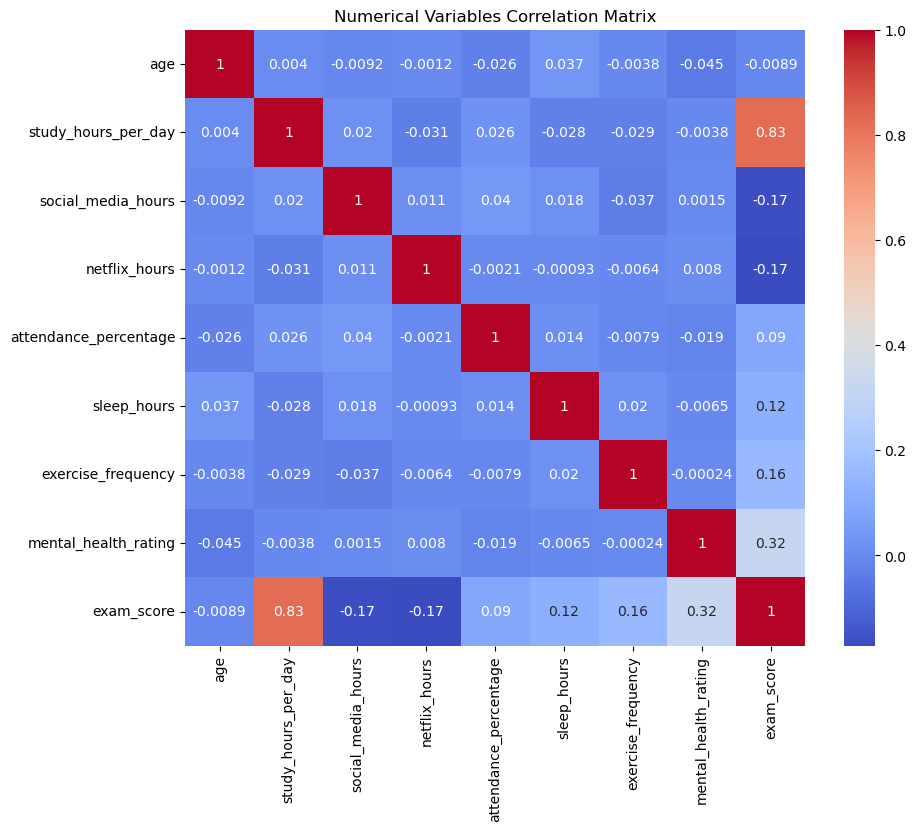

In [21]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[num_col].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Numerical Variables Correlation Matrix")
plt.show()


In [ ]:
Overall Weak Correlations:

Most correlation coefficients are close to zero.

This means there is no strong linear relationship between the features (such as age, social media usage, Netflix viewing time, absenteeism rate, sleep duration) and the target variable, or among the features themselves.

Independence of Features:

Social media usage, Netflix viewing time, absenteeism rate, sleep duration, daily study hours, and exam scores are almost unrelated to each other.

The only exception is the correlation of 0.83 between daily study hours and exam scores, indicating that studying more tends to increase exam performance.

# Distribution of numerical variable

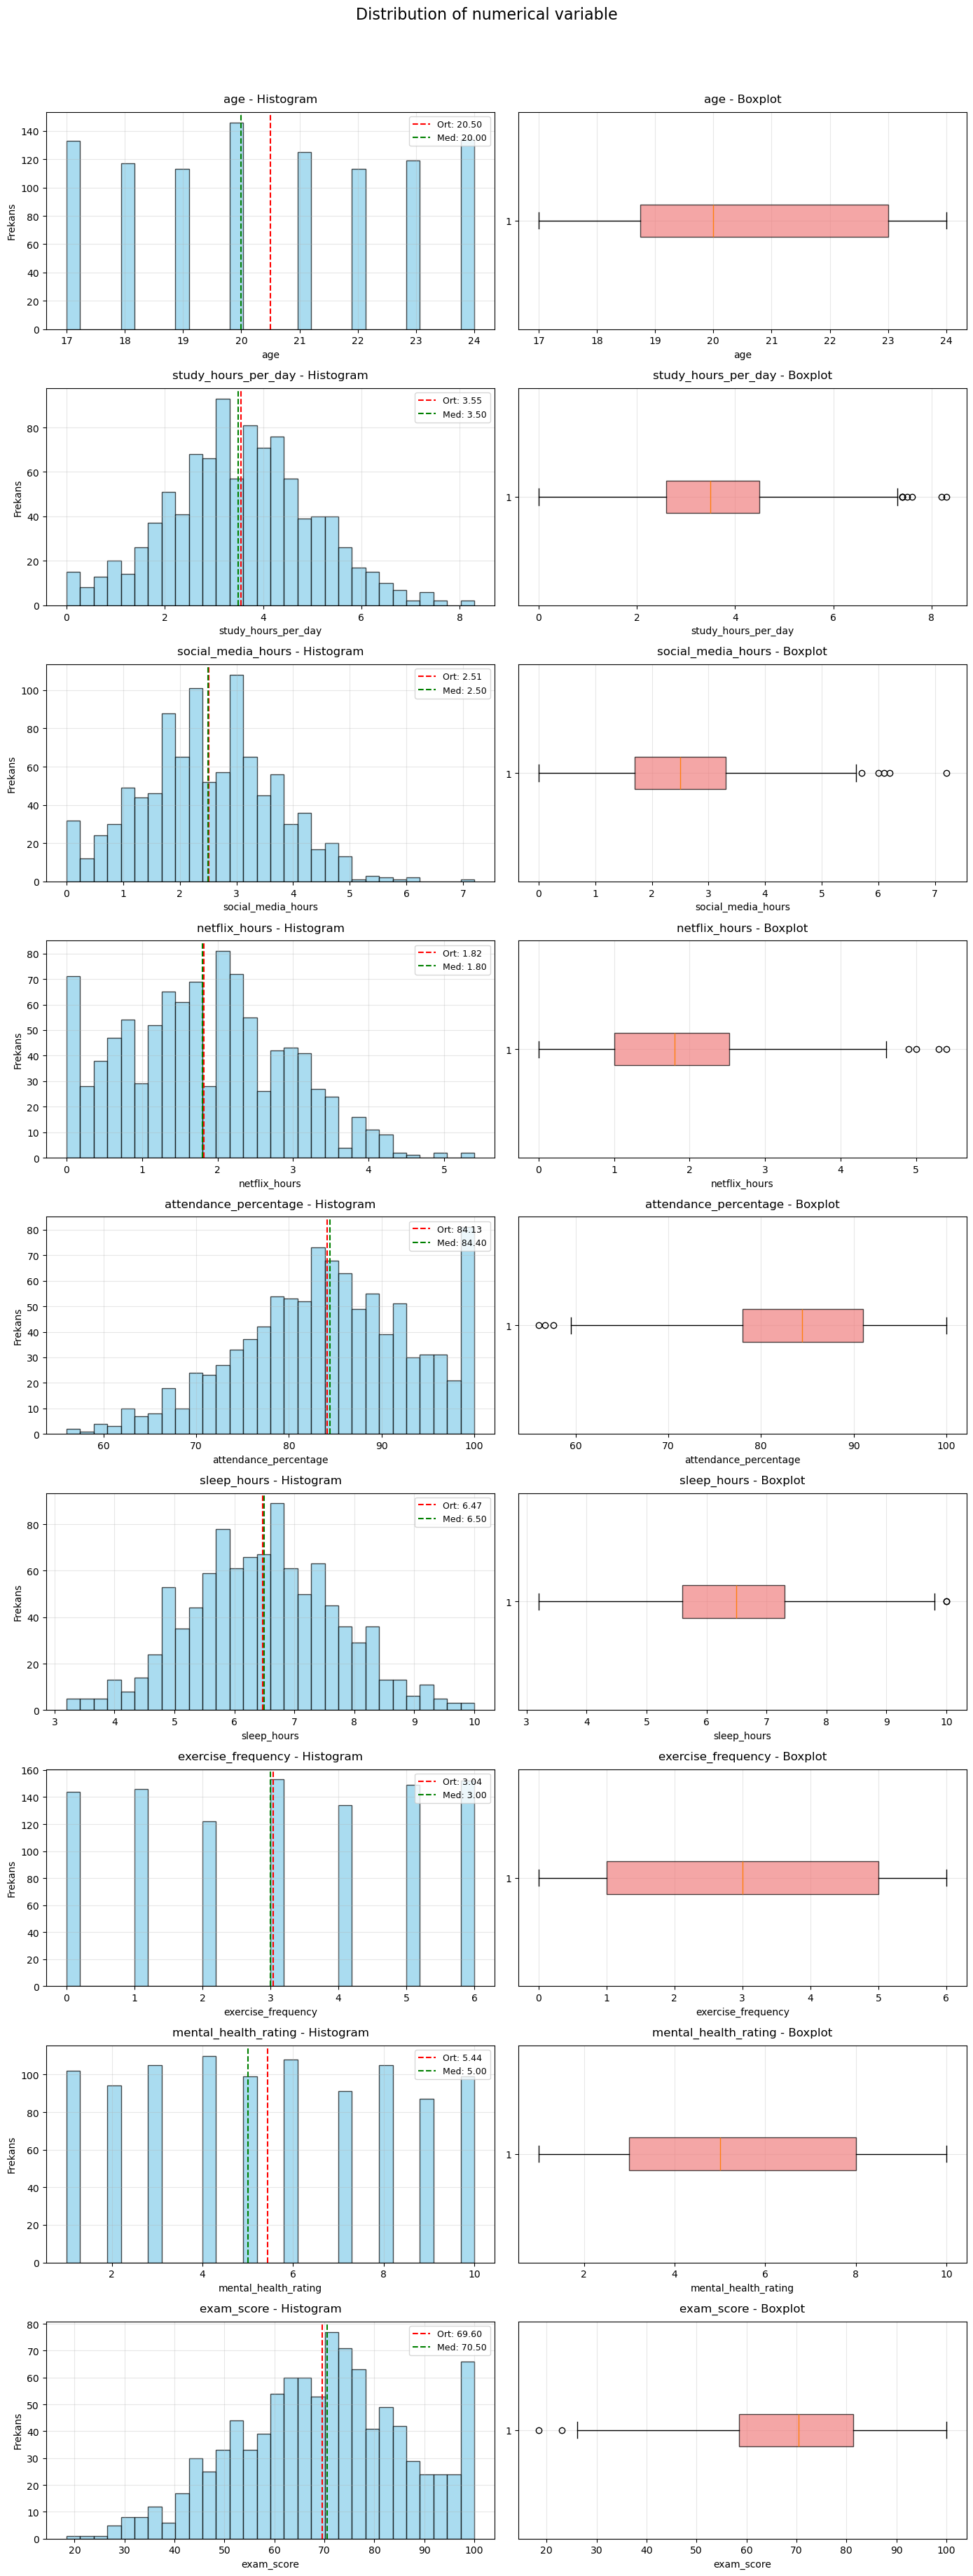

In [50]:
# Tüm sayısal değişkenler için görselleştirme
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4*len(numeric_cols)))
fig.suptitle('Distribution of numerical variable', fontsize=16, y=1.02)

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[i, 0].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Ort: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label=f'Med: {df[col].median():.2f}')
    axes[i, 0].set_title(f'{col} - Histogram', fontsize=12, pad=10)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frekans')
    axes[i, 0].legend(loc='upper right', fontsize=9)
    axes[i, 0].grid(alpha=0.3)
    
    # Boxplot
    axes[i, 1].boxplot(df[col], vert=False, patch_artist=True, 
                       boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[i, 1].set_title(f'{col} - Boxplot', fontsize=12, pad=10)
    axes[i, 1].set_xlabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
Insights on Numerical Feature Distributions¶
Shape and Spread of Distributions

Histograms reveal that all features are distributed fairly evenly across their respective ranges.
Boxplots confirm that the central 50% of values (the interquartile range), and the whiskers (showing the range).

# Categorical Feature distribution


DISTRIBUTION ANALYSIS OF CATEGORICAL VARIABLES


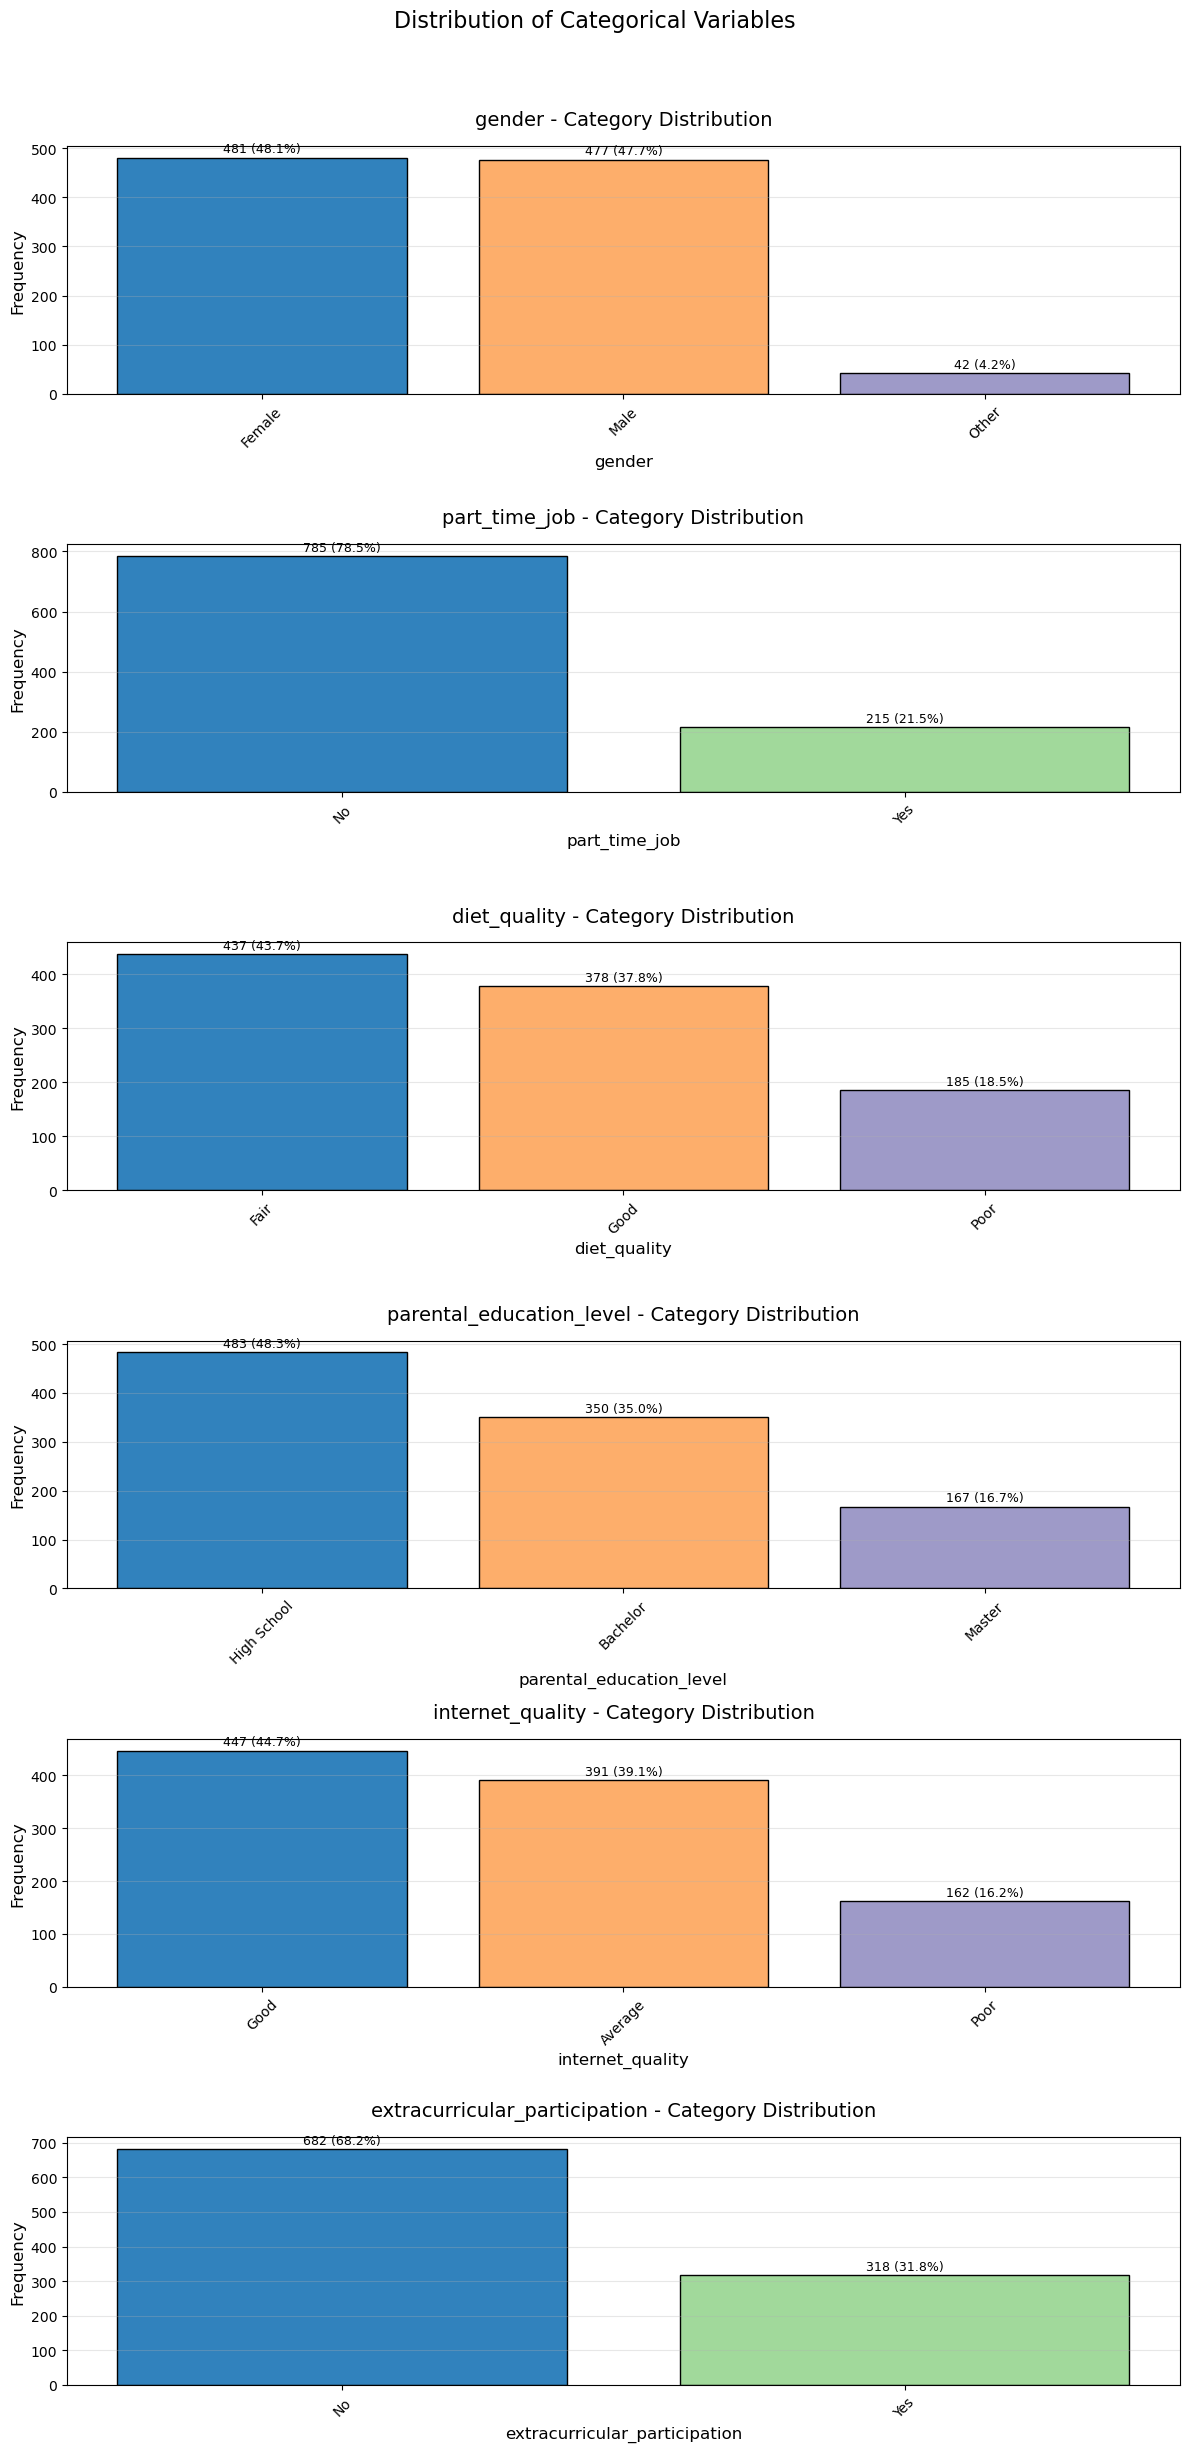

In [27]:
# 6. Analysis for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# 2. Remove 'student_id'
if 'student_id' in categorical_cols:
    categorical_cols.remove('student_id')

print("\n" + "="*70)
print("DISTRIBUTION ANALYSIS OF CATEGORICAL VARIABLES")
print("="*70)

# Visualization for categorical variables
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 4*len(categorical_cols)))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, y=1.02)

if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    colors = plt.cm.tab20c(np.arange(len(value_counts)) / len(value_counts))
    
    axes[i].bar(value_counts.index, value_counts.values, color=colors, edgecolor='black')
    axes[i].set_title(f'{col} - Category Distribution', fontsize=14, pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(alpha=0.3, axis='y')
    
    # Display values on top of the bars
    for idx, (category, count) in enumerate(value_counts.items()):
        axes[i].text(idx, count + max(value_counts.values)*0.01, 
                     f'{count} ({count/len(df)*100:.1f}%)', 
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()




DISTRIBUTION ANALYSIS OF CATEGORICAL VARIABLES


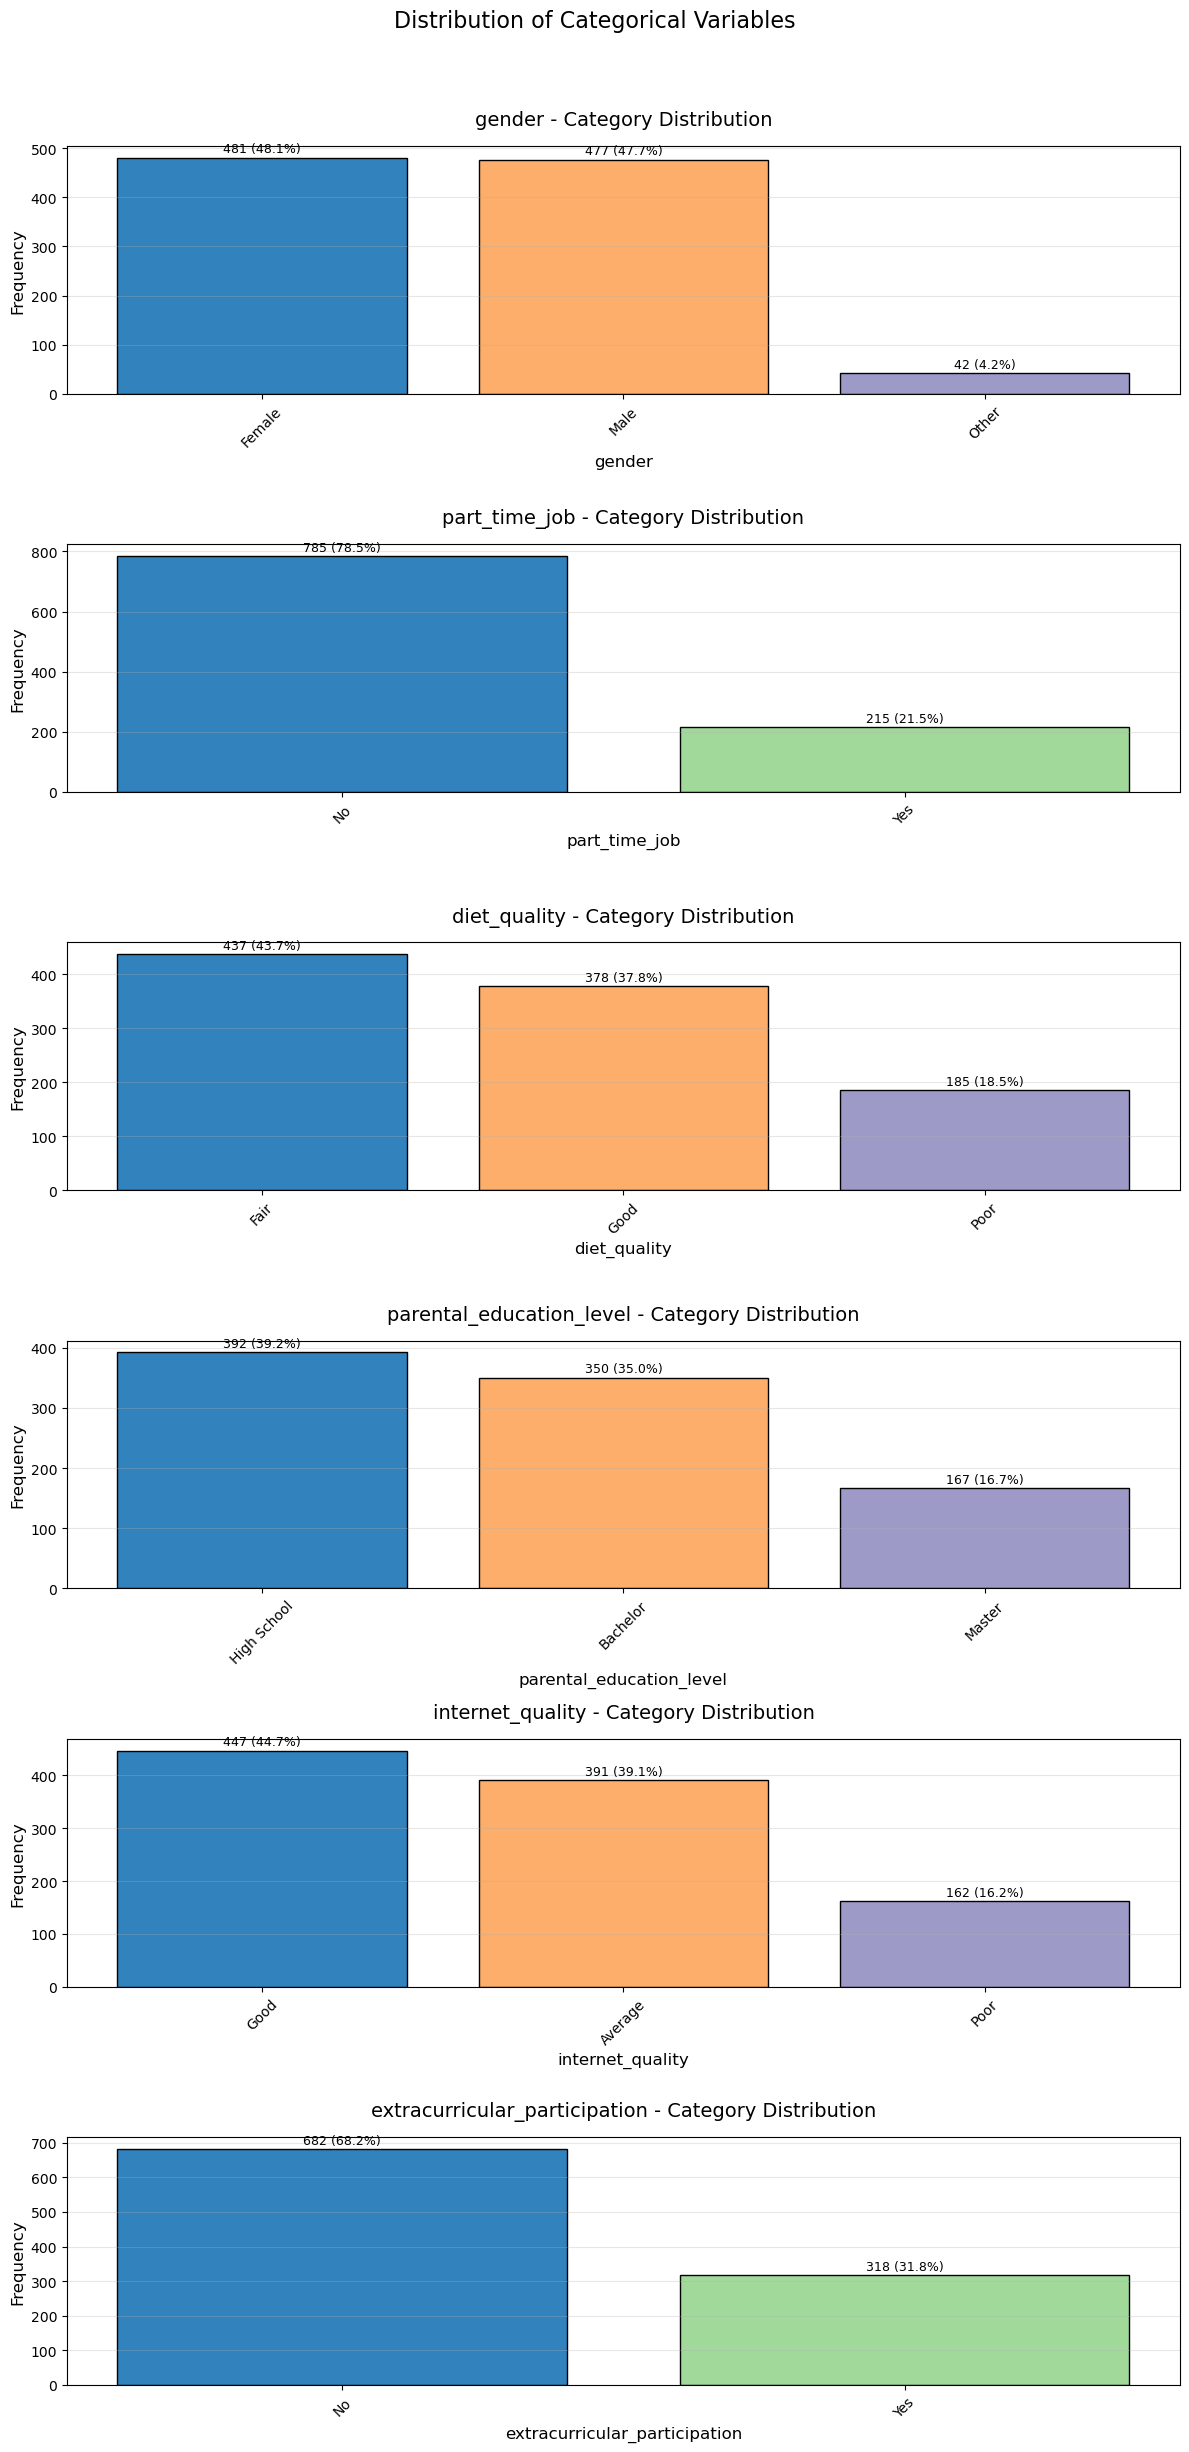

In [13]:
# 6. Analysis for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# 2. Remove student_id
if 'student_id' in categorical_cols:
    categorical_cols.remove('student_id')

print("\n" + "="*70)
print("DISTRIBUTION ANALYSIS OF CATEGORICAL VARIABLES")
print("="*70)

# Visualization for categorical variables
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 4*len(categorical_cols)))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, y=1.02)

if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    colors = plt.cm.tab20c(np.arange(len(value_counts)) / len(value_counts))
    
    axes[i].bar(value_counts.index, value_counts.values, color=colors, edgecolor='black')
    axes[i].set_title(f'{col} - Category Distribution', fontsize=14, pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(alpha=0.3, axis='y')
    
    # Write values on top of the bars
    for idx, (category, count) in enumerate(value_counts.items()):
        axes[i].text(
            idx,
            count + max(value_counts.values) * 0.01,
            f'{count} ({count/len(df)*100:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()


## Insights on Categorical Feature Distributions

The gender distribution shows that the number of female and male students is almost equal. This indicates a balanced gender distribution in the dataset.

The part_time_job distribution shows that the majority of students do not have a part-time job. This suggests that most students focus on their academic studies. However, students who work part-time may face additional challenges in terms of time management and stress levels.

The diet_quality distribution shows that there are more students in the Fair category than in the Good category. This means that students’ eating habits should be improved to help them move from Fair to Good.

The parental_education_level distribution shows that most students’ parents have a moderate education level, such as high school or a bachelor’s degree. Fewer students have parents with higher education levels, such as a master’s degree.

The internet_quality distribution shows that most students have average or good internet access. However, there is still a noticeable group of students who face internet access problems. This can be a barrier to equal learning opportunities.

The extracurricular_participation distribution shows that many students focus more on academics or personal time. As a result, extracurricular activities are not used enough for social skill development, networking, and stress relief. Schools or institutions can encourage students to have a more balanced life alongside academics.






In [29]:
# 7. Detailed table for categorical variables
print("\nDETAILED CATEGORICAL VARIABLE INFORMATION:")
print("-"*50)
for col in categorical_cols:
    value_counts = df[col].value_counts()
    print(f"\n{col.upper()}:")
    print(f"Total unique values: {df[col].nunique()}")
    print("Values and frequencies:")
    for category, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  - {category}: {count} ({percentage:.2f}%)")



DETAILED CATEGORICAL VARIABLE INFORMATION:
--------------------------------------------------

GENDER:
Total unique values: 3
Values and frequencies:
  - Female: 481 (48.10%)
  - Male: 477 (47.70%)
  - Other: 42 (4.20%)

PART_TIME_JOB:
Total unique values: 2
Values and frequencies:
  - No: 785 (78.50%)
  - Yes: 215 (21.50%)

DIET_QUALITY:
Total unique values: 3
Values and frequencies:
  - Fair: 437 (43.70%)
  - Good: 378 (37.80%)
  - Poor: 185 (18.50%)

PARENTAL_EDUCATION_LEVEL:
Total unique values: 3
Values and frequencies:
  - High School: 483 (48.30%)
  - Bachelor: 350 (35.00%)
  - Master: 167 (16.70%)

INTERNET_QUALITY:
Total unique values: 3
Values and frequencies:
  - Good: 447 (44.70%)
  - Average: 391 (39.10%)
  - Poor: 162 (16.20%)

EXTRACURRICULAR_PARTICIPATION:
Total unique values: 2
Values and frequencies:
  - No: 682 (68.20%)
  - Yes: 318 (31.80%)


In [11]:
## 1. AVERAGE EXAM SCORES BY DIET_QUALITY GROUPS

DIET QUALITY vs EXAM SCORE ANALYSIS

📈 STATISTICS OF DIET GROUPS:
               mean    std  count
diet_quality                     
Fair          70.43  16.65    437
Good          69.37  17.07    378
Poor          68.13  17.06    185


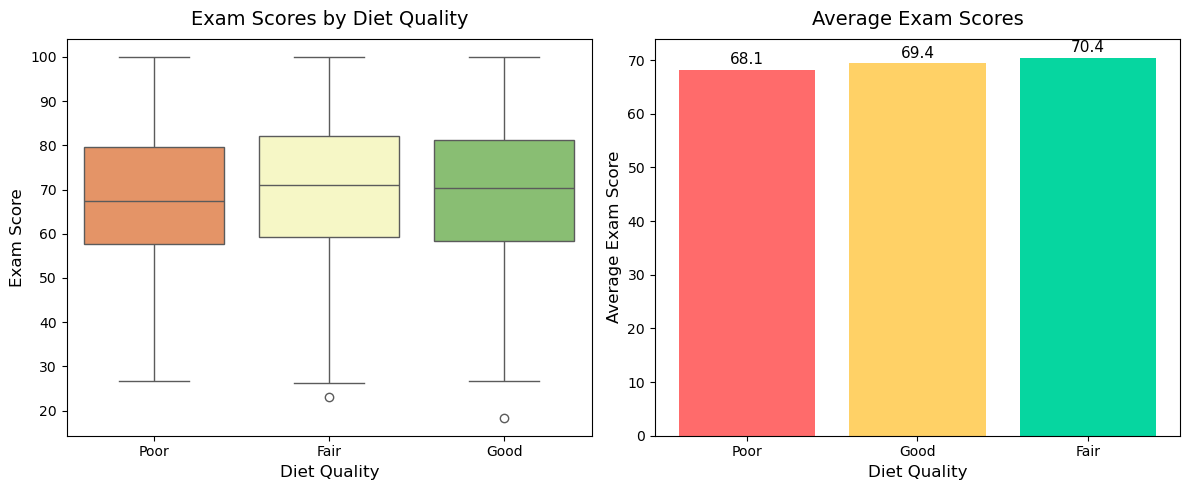


📊 STATISTICAL TEST:
----------------------------------------
Kruskal-Wallis H Test:
  H-statistic: 2.460
  p-value: 0.2923
  ❌ RESULT: No statistically significant difference between groups (p = 0.2923)


In [52]:
# 1. AVERAGE EXAM SCORES BY DIET_QUALITY GROUPS

print("DIET QUALITY vs EXAM SCORE ANALYSIS")


diet_scores = df.groupby('diet_quality')['exam_score'].agg(['mean', 'std', 'count']).round(2)
print("\n📈 STATISTICS OF DIET GROUPS:")
print(diet_scores)

# 2. VISUALIZATION
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(
    x='diet_quality',
    y='exam_score',
    data=df,
    order=['Poor', 'Fair', 'Good'],
    palette='RdYlGn'
)
plt.title('Exam Scores by Diet Quality', fontsize=14, pad=10)
plt.xlabel('Diet Quality', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

# Bar plot (mean exam scores)
plt.subplot(1, 2, 2)
diet_means = df.groupby('diet_quality')['exam_score'].mean().sort_values()
bars = plt.bar(
    diet_means.index,
    diet_means.values,
    color=['#ff6b6b', '#ffd166', '#06d6a0']
)
plt.title('Average Exam Scores', fontsize=14, pad=10)
plt.xlabel('Diet Quality', fontsize=12)
plt.ylabel('Average Exam Score', fontsize=12)

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.5,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 3. STATISTICAL TEST
print("\n📊 STATISTICAL TEST:")
print("-" * 40)

from scipy import stats

# Separate groups
poor_scores = df[df['diet_quality'] == 'Poor']['exam_score']
fair_scores = df[df['diet_quality'] == 'Fair']['exam_score']
good_scores = df[df['diet_quality'] == 'Good']['exam_score']

# Kruskal-Wallis test (comparison of 3 groups)
stat, p_value = stats.kruskal(poor_scores, fair_scores, good_scores)
print("Kruskal-Wallis H Test:")
print(f"  H-statistic: {stat:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print("  ✅ RESULT: There is a STATISTICALLY significant difference between groups (p < 0.05)")
    
    # Post-hoc test (which groups are different?)
    print("\n  🔍 POST-HOC ANALYSIS (Mann-Whitney U):")
    
    # Poor vs Fair
    u1, p1 = stats.mannwhitneyu(poor_scores, fair_scores)
    print(f"    Poor vs Fair: p = {p1:.4f} {'(different)' if p1 < 0.05 else '(no difference)'}")
    
    # Poor vs Good
    u2, p2 = stats.mannwhitneyu(poor_scores, good_scores)
    print(f"    Poor vs Good: p = {p2:.4f} {'(different)' if p2 < 0.05 else '(no difference)'}")
    
    # Fair vs Good
    u3, p3 = stats.mannwhitneyu(fair_scores, good_scores)
    print(f"    Fair vs Good: p = {p3:.4f} {'(different)' if p3 < 0.05 else '(no difference)'}")
    
else:
    print(f"  ❌ RESULT: No statistically significant difference between groups (p = {p_value:.4f})")


DIET_QUALITY vs EXAM_SCORE ANALİZİ

Insight
According to the Kruskal-Wallis test and above plots, there is no significant difference in exam scores across the different diet quality groups (p ≥ 0.05). This suggests that diet quality (Fair, Good, Poor) does not have a clear impact on exam score in this dataset.

PARENTAL_EDUCATION_LEVEL vs EXAM_SCORE ANALİZİ

PARENTAL EDUCATION LEVEL vs EXAM SCORE ANALYSIS

📈 STATISTICS BY PARENTAL EDUCATION LEVEL:
                           mean    std  count   min    max
parental_education_level                                  
Bachelor                  70.27  17.29    350  18.4  100.0
High School               69.64  16.77    483  23.1  100.0
Master                    68.09  16.40    167  26.8  100.0


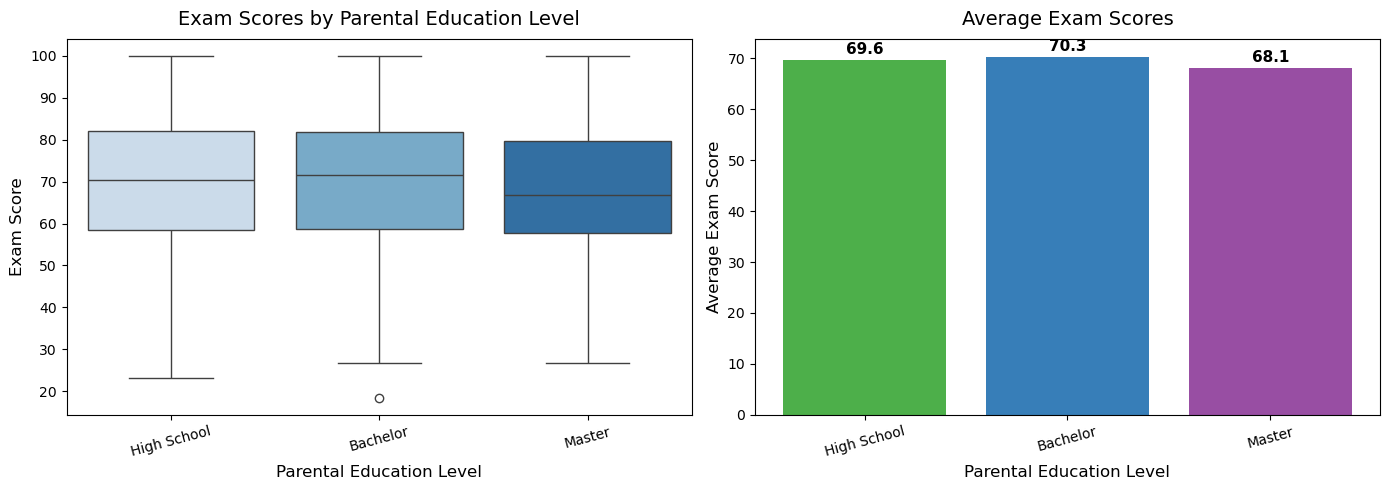


📊 STATISTICAL TEST:
--------------------------------------------------
Kruskal-Wallis H Test:
  H-statistic: 3.017
  p-value: 0.2213
  ❌ RESULT: No statistically significant difference between groups (p = 0.2213)

📏 EFFECT SIZE ANALYSIS:
--------------------------------------------------
High School → Bachelor: 0.63 point difference
High School → Master: -1.55 point difference
Bachelor → Master: -2.19 point difference

Increase relative to High School:
  Bachelor: %0.9
  Master: %-2.2


In [15]:
print("="*70)
print("PARENTAL EDUCATION LEVEL vs EXAM SCORE ANALYSIS")
print("="*70)

# 1. GROUP STATISTICS
parental_stats = df.groupby('parental_education_level')['exam_score'] \
    .agg(['mean', 'std', 'count', 'min', 'max']).round(2)

print("\n📈 STATISTICS BY PARENTAL EDUCATION LEVEL:")
print(parental_stats)

# 2. VISUALIZATION
plt.figure(figsize=(14, 5))

# Boxplot
plt.subplot(1, 2, 1)
order = ['High School', 'Bachelor', 'Master']
sns.boxplot(
    x='parental_education_level',
    y='exam_score',
    data=df,
    order=order,
    palette='Blues'
)
plt.title('Exam Scores by Parental Education Level', fontsize=14, pad=10)
plt.xlabel('Parental Education Level', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.xticks(rotation=15)

# Bar plot (mean scores)
plt.subplot(1, 2, 2)
parental_means = df.groupby('parental_education_level')['exam_score'].mean().loc[order]
bars = plt.bar(
    parental_means.index,
    parental_means.values,
    color=['#4daf4a', '#377eb8', '#984ea3']
)
plt.title('Average Exam Scores', fontsize=14, pad=10)
plt.xlabel('Parental Education Level', fontsize=12)
plt.ylabel('Average Exam Score', fontsize=12)
plt.xticks(rotation=15)

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.5,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 3. STATISTICAL TEST
print("\n📊 STATISTICAL TEST:")
print("-" * 50)

from scipy import stats

# Split groups
hs_scores = df[df['parental_education_level'] == 'High School']['exam_score']
bachelor_scores = df[df['parental_education_level'] == 'Bachelor']['exam_score']
master_scores = df[df['parental_education_level'] == 'Master']['exam_score']

# Kruskal-Wallis test (comparison of 3 groups)
stat, p_value = stats.kruskal(hs_scores, bachelor_scores, master_scores)
print("Kruskal-Wallis H Test:")
print(f"  H-statistic: {stat:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print("  ✅ RESULT: There is a STATISTICALLY significant difference between groups (p < 0.05)")
    
    # Post-hoc test (which groups differ?)
    print("\n  🔍 POST-HOC ANALYSIS (Mann-Whitney U):")
    
    # High School vs Bachelor
    u1, p1 = stats.mannwhitneyu(hs_scores, bachelor_scores)
    sig1 = "✓" if p1 < 0.05 else "✗"
    print(f"    High School vs Bachelor: p = {p1:.4f} {sig1} "
          f"{'(significant difference)' if p1 < 0.05 else '(no difference)'}")
    
    # High School vs Master
    u2, p2 = stats.mannwhitneyu(hs_scores, master_scores)
    sig2 = "✓" if p2 < 0.05 else "✗"
    print(f"    High School vs Master: p = {p2:.4f} {sig2} "
          f"{'(significant difference)' if p2 < 0.05 else '(no difference)'}")
    
    # Bachelor vs Master
    u3, p3 = stats.mannwhitneyu(bachelor_scores, master_scores)
    sig3 = "✓" if p3 < 0.05 else "✗"
    print(f"    Bachelor vs Master: p = {p3:.4f} {sig3} "
          f"{'(significant difference)' if p3 < 0.05 else '(no difference)'}")
    
else:
    print(f"  ❌ RESULT: No statistically significant difference between groups (p = {p_value:.4f})")

# 4. ADDITIONAL ANALYSIS: EFFECT SIZE
print("\n📏 EFFECT SIZE ANALYSIS:")
print("-" * 50)

# Calculate mean differences
mean_hs = hs_scores.mean()
mean_bachelor = bachelor_scores.mean()
mean_master = master_scores.mean()

print(f"High School → Bachelor: {mean_bachelor - mean_hs:.2f} point difference")
print(f"High School → Master: {mean_master - mean_hs:.2f} point difference")
print(f"Bachelor → Master: {mean_master - mean_bachelor:.2f} point difference")

# Percentage increase
print("\nIncrease relative to High School:")
print(f"  Bachelor: %{((mean_bachelor / mean_hs) - 1) * 100:.1f}")
print(f"  Master: %{((mean_master / mean_hs) - 1) * 100:.1f}")


In [ ]:
Insight The distribution of scores between groups is not significantly different. And based on the results from the Kruskal-Wallis test, it can be seen that parental education level has no clear impact on exam score in the dataset.

In [ ]:
PART_TIME_JOB vs exam score

PART-TIME JOB STATUS vs EXAM SCORE ANALYSIS

📈 STATISTICS BY PART-TIME JOB STATUS:
                mean    std  count
part_time_job                     
No             69.84  16.98    785
Yes            68.74  16.58    215


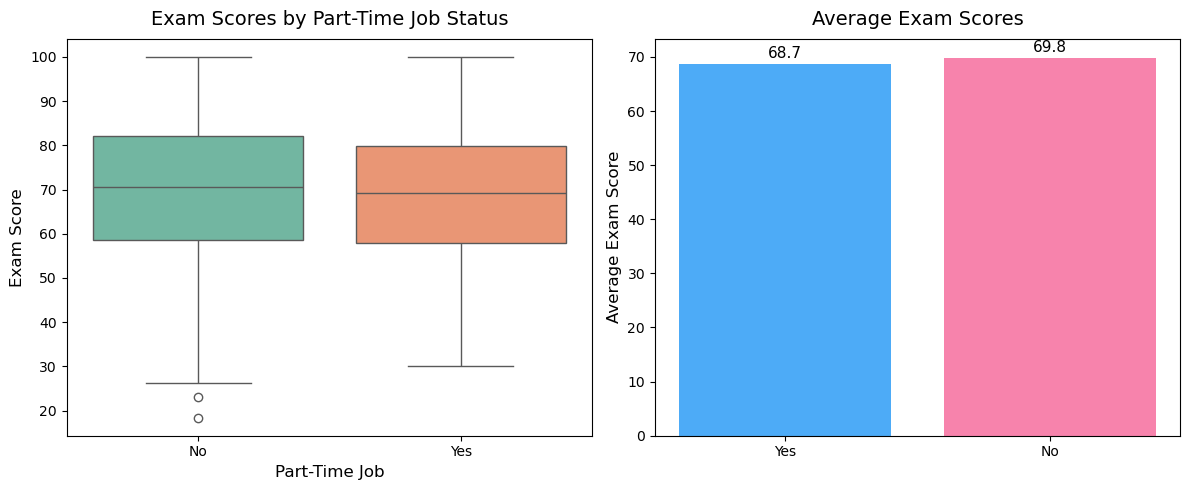


📊 STATISTICAL TEST:
----------------------------------------
Mann-Whitney U Test:
  U-statistic: 87986.500
  p-value: 0.3375
  ❌ RESULT: There is NO statistically significant difference in exam scores by part-time job status (p = 0.3375)


In [17]:
# 1. AVERAGE EXAM SCORES BY PART-TIME JOB STATUS
print("="*60)
print("PART-TIME JOB STATUS vs EXAM SCORE ANALYSIS")
print("="*60)

job_scores = df.groupby('part_time_job')['exam_score'].agg(['mean', 'std', 'count']).round(2)
print("\n📈 STATISTICS BY PART-TIME JOB STATUS:")
print(job_scores)

# 2. VISUALIZATION
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(
    x='part_time_job',
    y='exam_score',
    data=df,
    order=['No', 'Yes'],
    palette='Set2'
)
plt.title('Exam Scores by Part-Time Job Status', fontsize=14, pad=10)
plt.xlabel('Part-Time Job', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

# Bar plot (average scores)
plt.subplot(1, 2, 2)
job_means = df.groupby('part_time_job')['exam_score'].mean().sort_values()
bars = plt.bar(job_means.index, job_means.values, color=['#4dabf7', '#f783ac'])
plt.title('Average Exam Scores', fontsize=14, pad=10)
plt.ylabel('Average Exam Score', fontsize=12)

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.5,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 3. STATISTICAL TEST
print("\n📊 STATISTICAL TEST:")
print("-" * 40)

from scipy import stats

# Split groups
no_job_scores = df[df['part_time_job'] == 'No']['exam_score']
yes_job_scores = df[df['part_time_job'] == 'Yes']['exam_score']

# Mann-Whitney U test (comparison of 2 groups)
u_stat, p_value = stats.mannwhitneyu(no_job_scores, yes_job_scores)
print("Mann-Whitney U Test:")
print(f"  U-statistic: {u_stat:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print("  ✅ RESULT: There is a STATISTICALLY significant difference in exam scores by part-time job status (p < 0.05)")
else:
    print(f"  ❌ RESULT: There is NO statistically significant difference in exam scores by part-time job status (p = {p_value:.4f})")


The distribution of scores between groups is not significantly different. Based on the Mann-Whitney U test results, part-time job does not have a clear effect on exam scores in this dataset

In [ ]:
# Mental health rating vs exam score 

MENTAL HEALTH RATING vs EXAM SCORE ANALYSIS

📈 Basic Statistics:
       mental_health_rating  exam_score
count               1000.00     1000.00
mean                   5.44       69.60
std                    2.85       16.89
min                    1.00       18.40
25%                    3.00       58.48
50%                    5.00       70.50
75%                    8.00       81.32
max                   10.00      100.00


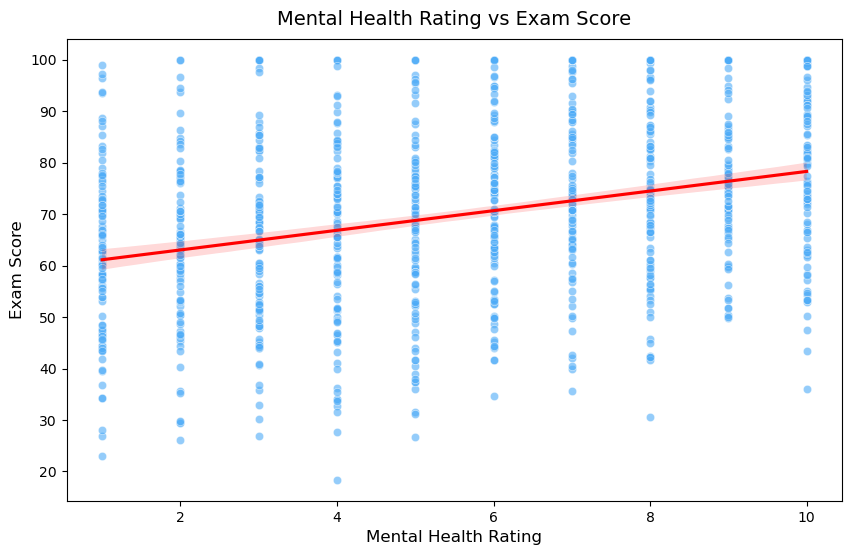


📊 CORRELATION TEST (Spearman):
  Correlation coefficient: 0.323
  p-value: 0.0000
  ✅ RESULT: There is a statistically significant relationship between mental health rating and exam score.


In [6]:
# 1. DESCRIPTIVE STATISTICS
print("="*60)
print("MENTAL HEALTH RATING vs EXAM SCORE ANALYSIS")
print("="*60)

mental_exam = df[['mental_health_rating', 'exam_score']].describe().round(2)
print("\n📈 Basic Statistics:")
print(mental_exam)

# 2. VISUALIZATION
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='mental_health_rating',
    y='exam_score',
    data=df,
    alpha=0.6,
    color='#4dabf7'
)
sns.regplot(
    x='mental_health_rating',
    y='exam_score',
    data=df,
    scatter=False,
    color='red'
)
plt.title('Mental Health Rating vs Exam Score', fontsize=14, pad=10)
plt.xlabel('Mental Health Rating', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.show()

# 3. CORRELATION ANALYSIS
from scipy.stats import spearmanr

corr, p_value = spearmanr(df['mental_health_rating'], df['exam_score'])
print("\n📊 CORRELATION TEST (Spearman):")
print(f"  Correlation coefficient: {corr:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print("  ✅ RESULT: There is a statistically significant relationship between mental health rating and exam score.")
else:
    print("  ❌ RESULT: There is no statistically significant relationship between mental health rating and exam score.")


There is a significant positive relationship between mental health rating and exam score (Spearman ρ = 0.323, p < 0.001), indicating that students with better mental health tend to achieve higher exam scores

insights Summary:
There is no significant difference between the scores of gender, part_time_job, diet_quality, parental_education_level, internet_quality and extracurricular_participation. Except for exercise_frequency and mental_health_rating, we also identified specific effects on exam scores through statistical testing.

# FINISH